In [24]:
import pandas as pd
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from pathlib import Path
from transformers import CLIPProcessor, CLIPModel
import torch
import importlib
import my_dataset
importlib.reload(my_dataset)
from my_dataset import Flickr8kDataset
import utils
importlib.reload(utils)
from utils import *



In [25]:
# ============= set project root
try:
    PROJECT_ROOT = Path(__file__).resolve().parents[1]
except NameError:
    # fallback for Jupyter notebooks
    PROJECT_ROOT = find_project_root()

# ============= PROJECT_ROOT = Path(__file__).resolve().parents[1]
DATA_DIR = PROJECT_ROOT / "data"
IMG_DIR = DATA_DIR / "Images"
CAPTIONS_FILE = DATA_DIR / "flickr8k_captions.csv"
RUNS_DIR = PROJECT_ROOT / "runs"

test_model = True

batch_size = 64
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    num_workers = 4
else:
    DEVICE = torch.device("cpu")
    num_workers = 0

In [26]:
# =========== load csv file with captions
captions = pd.read_csv(CAPTIONS_FILE, sep=";", engine="python")

# get unique images for proper splitting
images = captions["filename"].unique()

# split into train, val, test
train_imgs, test_imgs = train_test_split(images, test_size=0.2, random_state=42)
val_imgs, test_imgs = train_test_split(test_imgs, test_size=0.5, random_state=42)

# filter captions dataframe based on image splits
train_df = captions[captions["filename"].isin(train_imgs)]
val_df   = captions[captions["filename"].isin(val_imgs)]
test_df  = captions[captions["filename"].isin(test_imgs)]


# create datasets
train_dataset = Flickr8kDataset(str(IMG_DIR), train_df)
val_dataset   = Flickr8kDataset(str(IMG_DIR), val_df)
test_dataset  = Flickr8kDataset(str(IMG_DIR), test_df)

# create dataloaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

# Test the CLIP model on the test set and compute retrieval metrics
For basline comparision, we use the off-the-shelf CLIP model from Huggingface Transformers.

In [28]:
if test_model:
    import torch
    from transformers import CLIPProcessor, CLIPModel
    import matplotlib.pyplot as plt
    import os

    os.environ["TOKENIZERS_PARALLELISM"] = "false"

    device = "cuda" if torch.cuda.is_available() else "cpu"

    # Load off-the-shelf CLIP
    clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
    clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
    clip_model.eval()

    all_image_embs = []
    all_text_embs = []
    all_images = []
    all_texts = []

    # Compute embeddings for the whole test set
    with torch.no_grad():
        for batch_images, batch_texts in test_loader:
            # batch_images: PIL Images oder Tensoren (C,H,W)
            # batch_texts: Liste von Strings
            inputs = clip_processor(images=batch_images, text=batch_texts, padding=True, return_tensors="pt").to(device)

            image_embs = clip_model.get_image_features(pixel_values=inputs["pixel_values"])
            text_embs = clip_model.get_text_features(
                input_ids=inputs["input_ids"],
                attention_mask=inputs["attention_mask"]
            )

            # Normalize embeddings
            image_embs /= image_embs.norm(dim=-1, keepdim=True)
            text_embs /= text_embs.norm(dim=-1, keepdim=True)

            all_image_embs.append(image_embs)
            all_text_embs.append(text_embs)
            all_images.extend(batch_images)
            all_texts.extend(batch_texts)

    # Concatenate all batches
    all_image_embs = torch.cat(all_image_embs, dim=0)
    all_text_embs = torch.cat(all_text_embs, dim=0)

    # Compute similarity matrix
    sims = all_image_embs @ all_text_embs.T  # [num_images, num_texts]
    num_samples = len(all_texts)

    # ===== Compute Recall@K =====
    recall_at_1_text2img = 0
    recall_at_5_text2img = 0
    recall_at_10_text2img = 0

    recall_at_1_img2text = 0
    recall_at_5_img2text = 0
    recall_at_10_img2text = 0

    # Text -> Image
    for i in range(num_samples):
        topk = sims[i].topk(10).indices
        if i in topk[:1]:
            recall_at_1_text2img += 1
        if i in topk[:5]:
            recall_at_5_text2img += 1
        if i in topk[:10]:
            recall_at_10_text2img += 1

    # Image -> Text
    for i in range(num_samples):
        topk = sims[:, i].topk(10).indices
        if i in topk[:1]:
            recall_at_1_img2text += 1
        if i in topk[:5]:
            recall_at_5_img2text += 1
        if i in topk[:10]:
            recall_at_10_img2text += 1

    # Normalize
    recall_at_1_text2img /= num_samples
    recall_at_5_text2img /= num_samples
    recall_at_10_text2img /= num_samples

    recall_at_1_img2text /= num_samples
    recall_at_5_img2text /= num_samples
    recall_at_10_img2text /= num_samples

    print("=== CLIP Text -> Image ===")
    print(f"Recall@1: {recall_at_1_text2img:.4f}")
    print(f"Recall@5: {recall_at_5_text2img:.4f}")
    print(f"Recall@10: {recall_at_10_text2img:.4f}\n")

    print("=== CLIP Image -> Text ===")
    print(f"Recall@1: {recall_at_1_img2text:.4f}")
    print(f"Recall@5: {recall_at_5_img2text:.4f}")
    print(f"Recall@10: {recall_at_10_img2text:.4f}")

KeyboardInterrupt: 

# Test finetuned model
Here the finetuned model is tested on the test set and retrieval metrics are computed.

In [35]:
os.environ["TOKENIZERS_PARALLELISM"] = "false"

if test_model:
    # load finetuned model
    model_name = "openai/clip-vit-base-patch32"
    model = CLIPModel.from_pretrained(model_name)
    processor = CLIPProcessor.from_pretrained(model_name)
    model_path = "/Users/nicolasvogel/Dokumente/16_ZHAW_MSc/V5_9_Adcanced_Deep_Learning/ADL_multimodal-retrieval_Misc/251124_hpc_overfit_run/20251124_clip_cuda_sub-size-full_bs32_ep500_lr1e-05_ft_training_no-earlystop/20251124_clip_cuda_sub-size-full_bs32_ep500_lr1e-05_ft_training_no-earlystop_model.pth"
    model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))
    model.to(DEVICE)
    model.eval()

    all_image_embs = []
    all_text_embs = []
    num_samples = 0

    # compute embeddings for the entire test set
    with torch.no_grad():
        for batch_images, batch_texts in test_loader:
            inputs = processor(images=batch_images, text=batch_texts, padding=True, return_tensors="pt").to(DEVICE)

            image_embs = model.get_image_features(pixel_values=inputs["pixel_values"])
            text_embs = model.get_text_features(
                input_ids=inputs["input_ids"],
                attention_mask=inputs["attention_mask"]
            )

            # normalize embeddings
            image_embs = image_embs / image_embs.norm(dim=-1, keepdim=True)
            text_embs = text_embs / text_embs.norm(dim=-1, keepdim=True)

            all_image_embs.append(image_embs)
            all_text_embs.append(text_embs)
            num_samples += len(batch_texts)

    # concatenate all batches
    all_image_embs = torch.cat(all_image_embs, dim=0)
    all_text_embs = torch.cat(all_text_embs, dim=0)

    # compute similarity matrix
    sims = all_image_embs @ all_text_embs.T  # [num_images, num_texts]

    # Initialize recalls
    recall_at_1_text2img = 0
    recall_at_5_text2img = 0
    recall_at_10_text2img = 0

    recall_at_1_img2text = 0
    recall_at_5_img2text = 0
    recall_at_10_img2text = 0

    # Text -> Image
    for i in range(num_samples):
        topk = sims[i].topk(10).indices
        if i in topk[:1]:
            recall_at_1_text2img += 1
        if i in topk[:5]:
            recall_at_5_text2img += 1
        if i in topk[:10]:
            recall_at_10_text2img += 1

    # Image -> Text
    for i in range(num_samples):
        topk = sims[:, i].topk(10).indices
        if i in topk[:1]:
            recall_at_1_img2text += 1
        if i in topk[:5]:
            recall_at_5_img2text += 1
        if i in topk[:10]:
            recall_at_10_img2text += 1

    # Normalize recalls
    recall_at_1_text2img /= num_samples
    recall_at_5_text2img /= num_samples
    recall_at_10_text2img /= num_samples

    recall_at_1_img2text /= num_samples
    recall_at_5_img2text /= num_samples
    recall_at_10_img2text /= num_samples

    # Print results
    print("=== Text -> Image ===")
    print(f"Recall@1: {recall_at_1_text2img:.4f}")
    print(f"Recall@5: {recall_at_5_text2img:.4f}")
    print(f"Recall@10: {recall_at_10_text2img:.4f}\n")

    print("=== Image -> Text ===")
    print(f"Recall@1: {recall_at_1_img2text:.4f}")
    print(f"Recall@5: {recall_at_5_img2text:.4f}")
    print(f"Recall@10: {recall_at_10_img2text:.4f}")

=== Text -> Image ===
Recall@1: 0.0067
Recall@5: 0.0215
Recall@10: 0.0348

=== Image -> Text ===
Recall@1: 0.0059
Recall@5: 0.0326
Recall@10: 0.0570


1999


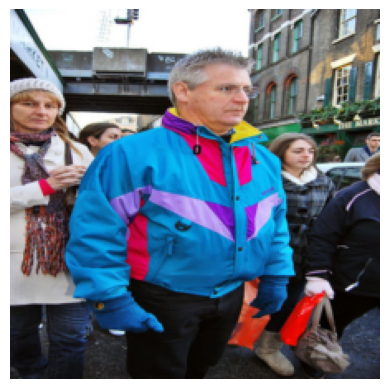

Top 5 retrieved captions:
- A little girl in a blue coat is rocking on a red playground toy .
- Two men are standing in front of a protest sign resting on a red electric box .
- There is a man in red and two children looking at a large , round , colorful wheel .
- Four young people stand near a bike with two flags on it .
- A little girl sits on a Farris wheel seat next to a giant stuffed animal .

Real captions:
- A man in a blue jacket and gloves is standing in the street among other people .
- A man in a brightly-colored ski jacket stands with others on a European street .
- A man in a colorful jacket walks down the street surrounded by women in winter clothing .
- The man in a blue jacket is standing in a crowd .
- The man in the blue jacket is walking in a crowd of people past an English pub .


In [44]:
# example with test data: random image and its top 5 retrieved captions
if test_model:
    import random
    random_idx = random.randint(0, len(test_dataset)-1)
    print(random_idx)
    random_image, _ = test_dataset[random_idx]
    inputs = processor(images=random_image, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        image_emb = model.get_image_features(pixel_values=inputs["pixel_values"])
        image_emb = image_emb / image_emb.norm(dim=-1, keepdim=True)
    sims = image_emb @ all_text_embs.T  # [1, num_texts]
    topk = sims[0].topk(5).indices
    topk = topk.cpu().numpy()
    plt.imshow(random_image.permute(1, 2, 0))
    plt.axis("off")
    plt.show()
    print("Top 5 retrieved captions:")
    for idx in topk:
        print(f"- {test_dataset.captions.iloc[idx]['caption']}")

    # real caption of the image
    real_captions = test_dataset.captions[test_dataset.captions['filename'] == test_dataset.captions.iloc[random_idx]['filename']]['caption'].tolist()
    print("\nReal captions:")
    for caption in real_captions:
        print(f"- {caption}")